In [1]:
import pandas as pd 
import numpy as np  

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, Sequential
from keras.utils import to_categorical 

2023-05-29 13:42:43.298739: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Load the data.

In [2]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
# ANTIGENS = ['V4', 'T4', 'Q4', 'A2', 'N4']  # Only focus on the strong markers. 
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
TIMES = [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
TEST_PROPORTION = 0.25

In [3]:
# Filter the data to the strong antigens, first repliate, OT-1 cells, high concentration, and later. 
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       (data.index.get_level_values('Concentration') == '1uM') & 
                       (data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 30.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

# Normalize the data. 
df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index) 

In [4]:
group_size = 10

def avg(group): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res

averaged_df = df.groupby(['Peptide', 'Time']).apply(avg)

In [5]:
antigen = list(df.index.get_level_values('Peptide'))
time = list(df.index.get_level_values('Time'))

In [6]:
X = np.array(df.values)
y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
y = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_PROPORTION, random_state=42)

# Setup the autoencoder model. 

In [7]:
autoencoder = Sequential([
    # layers.Dense(15, activation='tanh'),
    layers.Dense(10, activation='tanh'),
    # layers.Dense(5, activation='relu'), # was swish
    layers.Dense(2, activation='linear', name="Bottleneck"), # The bottleneck. 
    # layers.Dense(5, activation='elu'), # was selu
    # layers.Dense(5, activation='selu'), # was not here before. 
    layers.Dense(len(ANTIGENS), activation='softmax', name="Output") # Predicting the input. 
])

In [8]:
autoencoder.compile(optimizer='adagrad', loss=losses.CategoricalCrossentropy(), metrics=['categorical_accuracy'])

In [10]:
tf.random.set_seed(42)

hist = autoencoder.fit(X_train, y_train,
                epochs=30,
                shuffle=True,
                validation_data=(X_test, y_test))

Epoch 1/30
19539/19539 [==============================] - 30s 2ms/step - loss: 1.3069 - categorical_accuracy: 0.4923 - val_loss: 1.2989 - val_categorical_accuracy: 0.4952
Epoch 2/30
19539/19539 [==============================] - 29s 2ms/step - loss: 1.2908 - categorical_accuracy: 0.4985 - val_loss: 1.2845 - val_categorical_accuracy: 0.4997
Epoch 3/30
19539/19539 [==============================] - 29s 2ms/step - loss: 1.2779 - categorical_accuracy: 0.5026 - val_loss: 1.2728 - val_categorical_accuracy: 0.5033
Epoch 4/30
19539/19539 [==============================] - 30s 2ms/step - loss: 1.2672 - categorical_accuracy: 0.5054 - val_loss: 1.2631 - val_categorical_accuracy: 0.5063
Epoch 5/30
19539/19539 [==============================] - 29s 1ms/step - loss: 1.2582 - categorical_accuracy: 0.5077 - val_loss: 1.2548 - val_categorical_accuracy: 0.5084
Epoch 6/30
19539/19539 [==============================] - 29s 2ms/step - loss: 1.2506 - categorical_accuracy: 0.5095 - val_loss: 1.2477 - val_cat

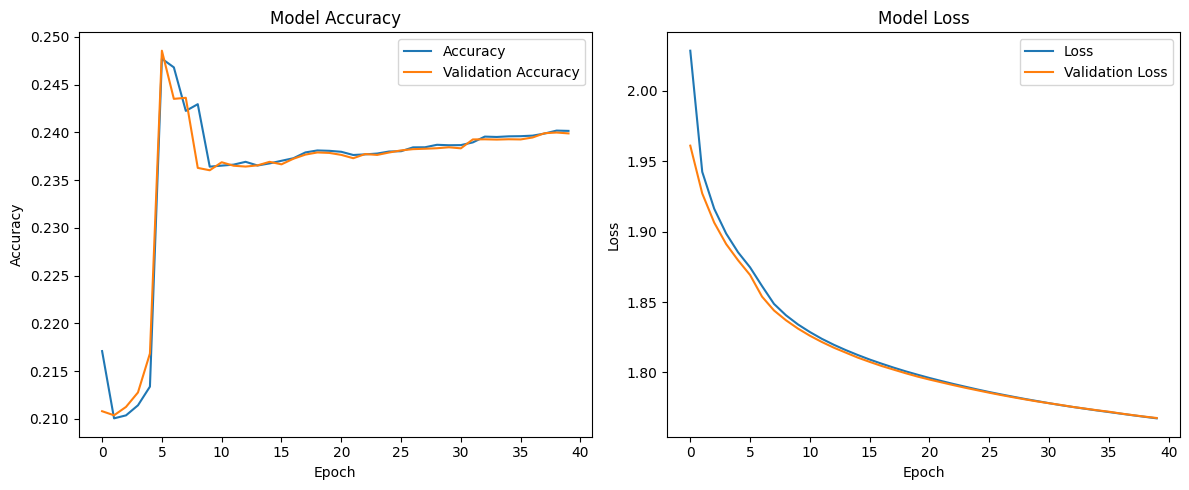

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot the accuracy on the first subplot
ax1.plot(hist.history['categorical_accuracy'], label='Accuracy')
ax1.plot(hist.history['val_categorical_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot the loss on the second subplot
ax2.plot(hist.history['loss'], label='Loss')
ax2.plot(hist.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

# Adjust the spacing between subplots
plt.tight_layout()

# Get the embedding from the bottleneck layer. 

In [ ]:
autoencoder.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 10)                270       
                                                                 
 Bottleneck (Dense)          (None, 2)                 22        
                                                                 
 Output (Dense)              (None, 8)                 24        
                                                                 
Total params: 316
Trainable params: 316
Non-trainable params: 0
_________________________________________________________________


In [ ]:
train_time, test_time = train_test_split(time, test_size=TEST_PROPORTION, random_state=42)
train_antigen, test_antigen = train_test_split(antigen, test_size=TEST_PROPORTION, random_state=42)

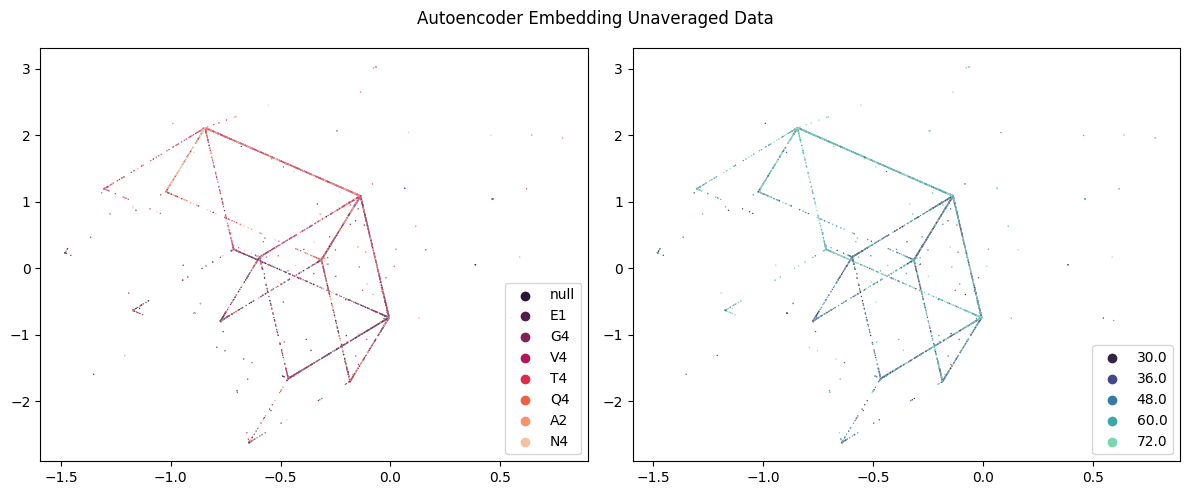

In [ ]:
extractor = Model(inputs=autoencoder.inputs,
                        outputs=autoencoder.get_layer("Bottleneck").output)
embedding = np.array( extractor(X_test) )

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_antigen), 
    palette="rocket", 
    hue_order=ANTIGENS,
    s=1, 
    ax=ax1
)

sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_time), 
    palette="mako", 
    s=1, 
    ax=ax2
)

fig.suptitle("Autoencoder Embedding Unaveraged Data")
ax1.legend(loc="lower right")
ax2.legend(loc="lower right")
plt.tight_layout()